# MZM PINN — Hyperparameter Tuning

Optuna-based hyperparameter search for the physics-informed `PINN` model defined in [MZM_MLP.ipynb](MZM_MLP.ipynb). This notebook reproduces that notebook's `PINN`/`MLP5` architecture, data pipeline, `train_model` training loop and the 8 soft physics constraints (`physics_penalty`/`PHYSICS_WEIGHTS`) verbatim.

The search tunes **only the 8 physics-constraint weights**, independently of one another (`w_dBW_dL`, `w_dIL_dL`, `w_dVpi_dL`, `w_d2IL_dPN2`, `w_d2Vpi_dPN2`, `w_dBW_dVbias`, `w_dVpi_dVbias`, `w_dIL_dVbias`) — so it can discover which constraints matter most and how strongly to enforce each. Architecture and optimizer hyperparameters (hidden dims, dropout, batch size, learning rate, weight decay) are held fixed at `PINN`'s defaults from `MZM_MLP.ipynb`, isolating the physics-weight effect from confounds like capacity or optimization settings.

Uses Optuna's TPE sampler with median pruning — `train_model`'s `trial` argument already reports per-epoch test loss for pruning, so no changes to the training loop were needed.


## Setup

In [26]:
# ==============================
# Import Required Libraries
# ==============================
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import re

from tqdm.auto import tqdm

import jax
import jax.numpy as jnp
import optax
from flax import nnx

import optuna

# Reproducibility
random_state = 123
np.random.seed(random_state)


## Model Definitions

In [27]:
BN_EPS = 1e-5
BN_MOMENTUM = 0.9


class MLP5(nnx.Module):
    """BatchNorm here is plain math over params it only reads (never
    mutates in place), so the whole forward pass is a pure function of
    (params, batch_stats, x)."""

    def __init__(
        self, input_dim=8, output_dim=3, dropout=0.2,
        hidden_dims=(200, 300, 350, 300, 200), *, rngs: nnx.Rngs,
    ):
        he = jax.nn.initializers.he_uniform()
        zeros = jax.nn.initializers.zeros

        def linear(d_in, d_out):
            return nnx.Linear(d_in, d_out, kernel_init=he, bias_init=zeros, rngs=rngs)

        def bn_params(d):
            return (
                nnx.Param(jnp.ones((d,))),
                nnx.Param(jnp.zeros((d,))),
                nnx.BatchStat(jnp.zeros((d,))),
                nnx.BatchStat(jnp.ones((d,))),
            )

        h1, h2, h3, h4, h5 = hidden_dims

        self.fc1 = linear(input_dim, h1)
        self.bn1_scale, self.bn1_bias, self.bn1_mean, self.bn1_var = bn_params(h1)

        self.fc2 = linear(h1, h2)
        self.bn2_scale, self.bn2_bias, self.bn2_mean, self.bn2_var = bn_params(h2)

        self.fc3 = linear(h2, h3)
        self.bn3_scale, self.bn3_bias, self.bn3_mean, self.bn3_var = bn_params(h3)

        self.fc4 = linear(h3, h4)
        self.bn4_scale, self.bn4_bias, self.bn4_mean, self.bn4_var = bn_params(h4)

        self.fc5 = linear(h4, h5)
        self.bn5_scale, self.bn5_bias, self.bn5_mean, self.bn5_var = bn_params(h5)

        self.output = linear(h5, output_dim)

        self.dropout = nnx.Dropout(dropout)

    def _block(self, x, fc, scale, bias, running_mean, running_var, *, train, rngs):
        x = fc(x)
        if train:
            mean = jnp.mean(x, axis=0)
            var = jnp.var(x, axis=0)
        else:
            mean, var = running_mean[...], running_var[...]
        x = (x - mean) / jnp.sqrt(var + BN_EPS) * scale[...] + bias[...]
        x = nnx.relu(x)
        x = self.dropout(x, deterministic=not train, rngs=rngs)
        return x, (mean, var)

    def __call__(self, x, *, train: bool, rngs=None):
        residual = x

        x, s1 = self._block(x, self.fc1, self.bn1_scale, self.bn1_bias, self.bn1_mean, self.bn1_var, train=train, rngs=rngs)
        x, s2 = self._block(x, self.fc2, self.bn2_scale, self.bn2_bias, self.bn2_mean, self.bn2_var, train=train, rngs=rngs)
        x, s3 = self._block(x, self.fc3, self.bn3_scale, self.bn3_bias, self.bn3_mean, self.bn3_var, train=train, rngs=rngs)
        x, s4 = self._block(x, self.fc4, self.bn4_scale, self.bn4_bias, self.bn4_mean, self.bn4_var, train=train, rngs=rngs)
        x, s5 = self._block(x, self.fc5, self.bn5_scale, self.bn5_bias, self.bn5_mean, self.bn5_var, train=train, rngs=rngs)
        batch_stats = {
            "bn1_mean": s1[0], "bn1_var": s1[1],
            "bn2_mean": s2[0], "bn2_var": s2[1],
            "bn3_mean": s3[0], "bn3_var": s3[1],
            "bn4_mean": s4[0], "bn4_var": s4[1],
            "bn5_mean": s5[0], "bn5_var": s5[1],
        }

        if residual.shape[-1] < x.shape[-1]:
            pad = x.shape[-1] - residual.shape[-1]
            residual = jnp.pad(residual, ((0, 0), (0, pad)))
        elif residual.shape[-1] > x.shape[-1]:
            residual = residual[:, : x.shape[-1]]

        x = x + residual

        return self.output(x), batch_stats

In [ ]:
class PINN(MLP5):
    """Physics-informed variant of MLP5: identical architecture and forward
    pass — the physics knowledge is injected purely through the training
    loss (see `physics_penalty` below and `train_model`'s `physics_weights`),
    not through any architecture change. Keeping the architecture identical
    to Base means every point in the comparisons below is automatically
    parameter-matched; any test-loss difference is attributable to the
    physics-informed loss term alone."""


# ==============================
# Physics-informed soft constraints
# ==============================
# Derivatives are taken on the *scaled* features/targets used during
# training. MinMaxScaler (features) and StandardScaler (targets) are both
# strictly increasing affine maps, so a derivative's sign in scaled space
# matches its sign in physical units — these constraints can be enforced
# directly on the training batch without unscaling.
#
# Feature columns: [PN_offset, Bias_V, Core_width, P+_width, N+_width,
#                    P_width, N_width, Phase_length]
PN_OFFSET_IDX = 0
BIAS_V_IDX = 1
PHASE_LENGTH_IDX = 7

# Target columns: [BW_3dB, IL, V_pi]
BW_IDX = 0
IL_IDX = 1
VPI_IDX = 2

# Per-constraint weights in train_model's combined training objective (see
# physics_penalty below) — each constraint scales its own one-sided hinge
# penalty independently, rather than all sharing one factor, so they can be
# tuned (e.g. via Optuna) separately. All-zero disables the physics loss
# entirely (Base); keys match physics_residuals' return dict.
PHYSICS_WEIGHTS = {
    "dBW_dL": 1.0,       # constraint 1: dBW/dL <= 0
    "dIL_dL": 1.0,       # constraint 2: dIL/dL >= 0
    "dVpi_dL": 1.0,      # constraint 3: dVpi/dL <= 0
    "d2IL_dPN2": 1.0,    # constraint 4: d^2 IL/dPN^2 >= 0
    "d2Vpi_dPN2": 1.0,   # constraint 5: d^2 Vpi/dPN^2 >= 0
    "dBW_dVbias": 1.0,   # constraint 6: dBW/dVbias <= 0
    "dVpi_dVbias": 1.0,  # constraint 7: dVpi/dVbias <= 0
    "dIL_dVbias": 1.0,   # constraint 8: dIL/dVbias >= 0
}
ZERO_PHYSICS_WEIGHTS = {k: 0.0 for k in PHYSICS_WEIGHTS}


def physics_residuals(predict_fn, x):
    """The eight raw physics-constraint quantities for one input row `x`
    (shape (8,)), evaluated through `predict_fn(x) -> (3,)`:

        1) dBW/dL          required <= 0 (bandwidth falls off with longer phase length)
        2) dVpi/dL         required <= 0 (V_pi falls off with longer phase length)
        3) dIL/dL          required >= 0 (insertion loss grows with longer waveguide)
        4) d^2 IL/dPN^2    required >= 0 (IL is convex in the PN offset)
        5) d^2 Vpi/dPN^2   required >= 0 (V_pi is convex in the PN offset)
        6) dBW/dVbias      required <= 0 (bandwidth falls off with higher bias voltage)
        7) dVpi/dVbias     required <= 0 (V_pi falls off with higher bias voltage)
        8) dIL/dVbias      required >= 0 (insertion loss grows with higher bias voltage)

    Every derivative here is scalar-input (L, PN_offset or Vbias),
    vector-output (all 3 targets at once), so forward-mode AD
    (`jax.jacfwd`) gets each one in a single JVP pass instead of one
    reverse pass per target.
    """
    def with_L(v):
        return predict_fn(x.at[PHASE_LENGTH_IDX].set(v))

    def with_PN(v):
        return predict_fn(x.at[PN_OFFSET_IDX].set(v))

    def with_Vbias(v):
        return predict_fn(x.at[BIAS_V_IDX].set(v))

    d_dL = jax.jacfwd(with_L)(x[PHASE_LENGTH_IDX])               # (3,)
    d2_dPN2 = jax.jacfwd(jax.jacfwd(with_PN))(x[PN_OFFSET_IDX])  # (3,)
    d_dVbias = jax.jacfwd(with_Vbias)(x[BIAS_V_IDX])             # (3,)

    return {
        "dBW_dL": d_dL[BW_IDX],
        "dIL_dL": d_dL[IL_IDX],
        "dVpi_dL": d_dL[VPI_IDX],
        "d2IL_dPN2": d2_dPN2[IL_IDX],
        "d2Vpi_dPN2": d2_dPN2[VPI_IDX],
        "dBW_dVbias": d_dVbias[BW_IDX],
        "dVpi_dVbias": d_dVbias[VPI_IDX],
        "dIL_dVbias": d_dVbias[IL_IDX],
    }


def physics_penalty(predict_fn, x_batch, weights):
    """Weighted sum of the mean squared one-sided hinge violations of the
    eight constraints in `physics_residuals`, batched (vmapped) over
    `x_batch` (shape (batch, 8)). `weights` is a dict keyed like
    `physics_residuals`' return value (see PHYSICS_WEIGHTS above) — each
    constraint contributes `weights[key] * mean(hinge(residual) ** 2))`
    independently."""
    r = jax.vmap(lambda x: physics_residuals(predict_fn, x))(x_batch)
    hinge = {
        "dBW_dL": jax.nn.relu(r["dBW_dL"]),
        "dIL_dL": jax.nn.relu(-r["dIL_dL"]),
        "dVpi_dL": jax.nn.relu(r["dVpi_dL"]),
        "d2IL_dPN2": jax.nn.relu(-r["d2IL_dPN2"]),
        "d2Vpi_dPN2": jax.nn.relu(-r["d2Vpi_dPN2"]),
        "dBW_dVbias": jax.nn.relu(r["dBW_dVbias"]),
        "dVpi_dVbias": jax.nn.relu(r["dVpi_dVbias"]),
        "dIL_dVbias": jax.nn.relu(-r["dIL_dVbias"]),
    }
    return sum(weights[key] * jnp.mean(val ** 2) for key, val in hinge.items())


## Data Loading & Preprocessing

In [29]:
# ==============================
# Load and Preprocess Data
# ==============================
# from google.colab import drive
# drive.mount('/content/drive')
# file_path = "/content/drive/MyDrive/MZM Data/Sim_generated_dataset.txt"
file_path = "Sim_generated_dataset.txt"

In [30]:
with open(file_path) as f:
    cleaned = [re.sub(r'[\[\]]', '', line.strip()) for line in f]

df = pd.read_csv(StringIO("\n".join(cleaned)), header=None)
df.columns = [
    "PN_offset", "Bias_V", "Core_width", "P+_width", "N+_width",
    "P_width", "N_width", "Phase_length", "BW_3dB", "IL", "V_pi"
]

# Data cleaning: remove rows with extreme V_pi (>500, <0)
df_cleaned = df[(df['V_pi'] < 500) & (df['V_pi'] > 0)].copy()
print(f"Dataset size after cleaning: {len(df_cleaned)} samples")

# Split features / targets
feature_cols = df_cleaned.columns[:8]
target_cols = df_cleaned.columns[8:]

x = df_cleaned[feature_cols].values
y = df_cleaned[target_cols].values

# Train / test split
x_train_raw, x_test_raw, y_train_raw, y_test_raw = train_test_split(
    x, y, test_size=0.1, random_state=random_state
)

# ==============================
# Scaling (fit on TRAIN only)
# ==============================
scaler_x = MinMaxScaler()  # Features
scaler_y1 = StandardScaler()  # BW_3dB
scaler_y2 = StandardScaler()  # IL
scaler_y3 = StandardScaler()  # V_pi

x_train_scaled = scaler_x.fit_transform(x_train_raw)
y_train_scaled = np.hstack([
    scaler_y1.fit_transform(y_train_raw[:, 0:1]),
    scaler_y2.fit_transform(y_train_raw[:, 1:2]),
    scaler_y3.fit_transform(y_train_raw[:, 2:3]),
])

x_test_scaled = scaler_x.transform(x_test_raw)
y_test_scaled = np.hstack([
    scaler_y1.transform(y_test_raw[:, 0:1]),
    scaler_y2.transform(y_test_raw[:, 1:2]),
    scaler_y3.transform(y_test_raw[:, 2:3]),
])

# Convert to tensors
x_train_t = jnp.asarray(x_train_scaled, dtype=jnp.float32)
y_train_t = jnp.asarray(y_train_scaled, dtype=jnp.float32)
x_test_t  = jnp.asarray(x_test_scaled, dtype=jnp.float32)
y_test_t  = jnp.asarray(y_test_scaled, dtype=jnp.float32)

print(f"Train: {x_train_t.shape[0]} | Test: {x_test_t.shape[0]}")
df_cleaned.describe()

Dataset size after cleaning: 9614 samples
Train: 8652 | Test: 962


,PN_offset,Bias_V,Core_width,P+_width,N+_width,P_width,N_width,Phase_length,BW_3dB,IL,V_pi
count,9.614000e+03,9614.000000,9.614000e+03,9.614000e+03,9.614000e+03,9.614000e+03,9.614000e+03,9614.000000,9614.000000,9614.000000,9614.000000
mean,-4.106982e-09,-5.965076,4.774007e-07,2.584718e-07,2.618829e-07,7.853203e-07,7.904345e-07,0.002285,46.011836,1.577726,33.900601
std,1.272187e-07,2.251585,2.488443e-08,1.315607e-07,1.370419e-07,1.293550e-07,1.313482e-07,0.001030,13.757979,0.896971,31.995194
min,-2.150000e-07,-10.000000,4.050720e-07,4.509540e-08,4.500550e-08,4.510390e-07,4.501570e-07,0.000500,2.256410,0.166187,3.564810
25%,-1.064180e-07,-7.874185,4.613922e-07,1.472730e-07,1.420500e-07,6.774380e-07,6.796328e-07,0.001415,34.923077,0.881409,14.321325
50%,0.000000e+00,-5.819890,4.754365e-07,2.522630e-07,2.602395e-07,7.865730e-07,7.942275e-07,0.002229,44.974359,1.394790,23.757300
75%,9.655928e-08,-4.041150,4.891833e-07,3.689188e-07,3.806483e-07,8.958177e-07,9.036680e-07,0.003167,54.800000,2.162227,41.027525
max,2.150000e-07,-2.250820,6.000000e-07,4.998190e-07,5.000000e-07,1.098400e-06,1.099670e-06,0.005971,74.000000,5.255890,394.839000


## GPU Setup

In [31]:
print(f"JAX devices: {jax.devices()}")
print(f"Using backend: {jax.default_backend()}")
print(f"x_train_t device: {x_train_t.device}")

JAX devices: [CudaDevice(id=0)]
Using backend: gpu
x_train_t device: cuda:0


## Training Function

In [32]:
def train_model(
    model_ctor,  # Callable[[nnx.Rngs], nnx.Module] — builds the model to train
    batch_size=16,
    learning_rate=1e-3,
    weight_decay=0.05,
    betas=(0.9, 0.999),
    n_epoch=100,
    physics_weights=None,
    verbose=False,
    trial=None,  # Optuna trial for pruning
    early_stopping_patience=20,
    early_stopping_min_delta=1e-5,
    restore_best_weights=True,
    seed=random_state,
    x_train=None,
    y_train=None,
):
    """
    Build, train and evaluate a model with the given hyperparameters.

    `model_ctor(rngs) -> nnx.Module` builds the model; any architecture is
    supported as long as `model.__call__(x, *, train, rngs=None)` returns
    `(pred, new_stats)`, where `new_stats` is a plain nested dict/int-keyed
    structure whose shape matches `nnx.to_pure_dict(nnx.state(model,
    nnx.BatchStat))` — see MLP5/PINN below for two conforming examples.

    `physics_weights` (a dict of per-constraint weights, see PHYSICS_WEIGHTS
    in Model Definitions; default None, i.e. Base) adds
    `physics_penalty(..., physics_weights)` (see Model Definitions) to the
    training loss — the physics penalty is evaluated in eval mode (no
    dropout, running BatchNorm stats) so its gradient is a clean function of
    the current weights, not of the batch's own composition. The MSE
    reported in the returned dict ('train_loss'/'test_loss'/histories) is
    always the plain data loss, unaffected by this term, so Base and PINN
    runs stay directly comparable. `physics_weights=None` or all-zero
    disables the physics loss entirely.

    x_train/y_train default to the module-level x_train_t/y_train_t but can be
    overridden (e.g. bootstrap-resampled or subsampled) for the comparison
    studies below; the held-out test set is always x_test_t/y_test_t.

    Each epoch's batches run as a single `jax.lax.scan` under one `jit` call
    instead of a Python loop dispatching one XLA call per batch, and per-split
    evaluation is a single whole-array forward pass instead of a batched loop
    — both avoid host/device round-trips that dominate runtime at this model
    size. Scanning over fixed-size batches means each epoch drops the last
    partial batch (equivalent to `drop_last=True`), which discards at most
    `batch_size - 1` samples per epoch.

    Returns
    -------
    dict with keys:
        'train_loss', 'test_loss',
        'train_history', 'test_history',
        'model_state'
    """
    x_train_data = x_train_t if x_train is None else x_train
    y_train_data = y_train_t if y_train is None else y_train

    physics_active = physics_weights is not None and any(
        w != 0.0 for w in physics_weights.values()
    )

    # --- Build model ---
    init_key, epoch_key = jax.random.split(jax.random.PRNGKey(seed))
    model = model_ctor(nnx.Rngs(init_key))
    graphdef, params, batch_stats = nnx.split(model, nnx.Param, nnx.BatchStat)

    n_params = sum(p.size for p in jax.tree_util.tree_leaves(params))

    tx = optax.adamw(
        learning_rate, weight_decay=weight_decay, b1=betas[0], b2=betas[1],
    )
    opt_state = tx.init(params)

    def apply_fn(params, batch_stats, x, dropout_key, train):
        m = nnx.merge(graphdef, params, batch_stats)
        dropout_rngs = nnx.Rngs(dropout=dropout_key) if train else None
        pred, new_stats = m(x, train=train, rngs=dropout_rngs)
        if not train:
            return pred, batch_stats
        new_batch_stats = jax.tree_util.tree_map(lambda a: a, batch_stats)
        old_pure = nnx.to_pure_dict(batch_stats)
        blended_pure = jax.tree_util.tree_map(
            lambda old, new: BN_MOMENTUM * old + (1 - BN_MOMENTUM) * new,
            old_pure, new_stats,
        )
        nnx.replace_by_pure_dict(new_batch_stats, blended_pure)
        return pred, new_batch_stats

    def loss_fn(params, batch_stats, x_batch, y_batch, dropout_key):
        pred, new_batch_stats = apply_fn(params, batch_stats, x_batch, dropout_key, True)
        data_loss = jnp.mean((pred - y_batch) ** 2)
        if not physics_active:
            return data_loss, new_batch_stats

        def predict_fn(x_row):
            p, _ = apply_fn(params, batch_stats, x_row[None, :], None, False)
            return p[0]

        loss = data_loss + physics_penalty(predict_fn, x_batch, physics_weights)
        return loss, new_batch_stats

    def train_step(params, batch_stats, opt_state, x_batch, y_batch, dropout_key):
        (loss, new_batch_stats), grads = jax.value_and_grad(loss_fn, has_aux=True)(
            params, batch_stats, x_batch, y_batch, dropout_key
        )
        updates, opt_state = tx.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, new_batch_stats, opt_state

    n_train = x_train_data.shape[0]
    n_batches = max(n_train // batch_size, 1)

    @jax.jit
    def run_epoch(params, batch_stats, opt_state, perm, drop_key):
        """One full epoch of training as a single scan (one XLA dispatch),
        instead of a Python loop issuing one dispatch per batch."""
        batch_idx = perm[: n_batches * batch_size].reshape(n_batches, batch_size)
        batch_keys = jax.random.split(drop_key, n_batches)

        def step(carry, xs):
            params, batch_stats, opt_state = carry
            idx, key = xs
            x_batch = x_train_data[idx]
            y_batch = y_train_data[idx]
            params, batch_stats, opt_state = train_step(
                params, batch_stats, opt_state, x_batch, y_batch, key
            )
            return (params, batch_stats, opt_state), None

        (params, batch_stats, opt_state), _ = jax.lax.scan(
            step, (params, batch_stats, opt_state), (batch_idx, batch_keys)
        )
        return params, batch_stats, opt_state

    @jax.jit
    def eval_loss(params, batch_stats, x, y):
        pred, _ = apply_fn(params, batch_stats, x, None, False)
        return jnp.mean((pred - y) ** 2)

    train_hist = np.zeros(n_epoch)
    test_hist  = np.zeros(n_epoch)

    # --- Early stopping bookkeeping ---
    best_test_loss = float('inf')
    best_epoch = -1
    epochs_without_improvement = 0
    best_state = None
    stopped_epoch = n_epoch - 1

    # --- Training loop ---
    epoch_iter = tqdm(
        range(n_epoch),
        desc="Training",
        dynamic_ncols=True,
        leave=False,
        colour="cyan",
        disable=not verbose,
    )

    for epoch in epoch_iter:
        epoch_key, perm_key, drop_key = jax.random.split(epoch_key, 3)
        perm = jax.random.permutation(perm_key, n_train)
        params, batch_stats, opt_state = run_epoch(params, batch_stats, opt_state, perm, drop_key)

        # --- Evaluation ---
        train_loss = float(eval_loss(params, batch_stats, x_train_data, y_train_data))
        test_loss = float(eval_loss(params, batch_stats, x_test_t, y_test_t))
        train_hist[epoch] = train_loss
        test_hist[epoch] = test_loss

        if verbose:
            epoch_iter.set_postfix({
                "train": f"{train_loss:.4e}",
                "test": f"{test_loss:.4e}",
                "best": f"{best_test_loss:.4e}" if np.isfinite(best_test_loss) else "inf",
            })

        # Optuna pruning
        if trial is not None:
            trial.report(test_loss, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        # Early stopping (based on test loss)
        if test_loss < (best_test_loss - early_stopping_min_delta):
            best_test_loss = test_loss
            best_epoch = epoch
            epochs_without_improvement = 0
            if restore_best_weights:
                best_state = (params, batch_stats)
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= early_stopping_patience:
            stopped_epoch = epoch
            if verbose:
                print(
                    f"Early stopping at epoch {epoch} (best epoch: {best_epoch}, best test: {best_test_loss:.6f})"
                )
            break

    # Keep only executed part of histories
    executed_epochs = stopped_epoch + 1
    train_hist = train_hist[:executed_epochs]
    test_hist = test_hist[:executed_epochs]

    # Restore best weights if requested and available
    if restore_best_weights and best_state is not None:
        params, batch_stats = best_state

    # Re-evaluate final model (restored best if enabled)
    final_train_loss = float(eval_loss(params, batch_stats, x_train_data, y_train_data))
    final_test_loss = float(eval_loss(params, batch_stats, x_test_t, y_test_t))

    return {
        'train_loss': final_train_loss,
        'test_loss':  final_test_loss,
        'best_test_loss': best_test_loss,
        'best_epoch': best_epoch,
        'stopped_epoch': stopped_epoch,
        'train_history': train_hist,
        'test_history':  test_hist,
        'model_state': (graphdef, params, batch_stats),
        'n_params': n_params,
    }


## Hyperparameter Search Configuration

Architecture and optimizer hyperparameters are fixed (see below); only the 8 physics-constraint weights are tuned. Search runs use a shorter epoch budget with early stopping to keep the sweep tractable; the best configuration found is retrained for longer below.


In [33]:
# ==============================
# Fixed Hyperparameters & Search Budget
# ==============================
# Everything except the physics-constraint weights is held fixed at PINN's
# defaults from MZM_MLP.ipynb (same architecture/optimizer as the canonical
# Base/PINN comparison there) — this search isolates the effect of the 8
# physics-constraint weights alone.
HIDDEN_DIMS = (200, 300, 350, 300, 200)
DROPOUT = 0.2
BATCH_SIZE = 16
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 0.05

# Number of Optuna trials
N_OPTUNA_TRIALS = 50

# Training epochs per trial (lower for faster search; retrain best with more)
SEARCH_EPOCHS = 60
SEARCH_PATIENCE = 15

# Final retraining budget for the best config
FINAL_EPOCHS = 200
FINAL_PATIENCE = 30


## Optuna Search
Uses a TPE sampler and median pruner. Pruning relies on `train_model`'s built-in per-epoch `trial.report`/`should_prune` support.

In [34]:
def objective(trial):
    # The only thing this search tunes: each of the 8 physics constraints
    # weighted independently. Architecture/optimizer hyperparameters are
    # held fixed (see Hyperparameter Search Configuration above).
    physics_weights = {
        key: trial.suggest_float(f"w_{key}", 0.0, 1.0) for key in PHYSICS_WEIGHTS
    }

    result = train_model(
        model_ctor=lambda rngs: PINN(input_dim=8, output_dim=3, dropout=DROPOUT,
                                      hidden_dims=HIDDEN_DIMS, rngs=rngs),
        batch_size=BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        physics_weights=physics_weights,
        n_epoch=SEARCH_EPOCHS,
        early_stopping_patience=SEARCH_PATIENCE,
        trial=trial,
        verbose=False,
    )
    return result["test_loss"]


In [35]:
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=random_state),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=20),
)
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

# --- Best trial summary ---
best = study.best_trial
print("\n" + "=" * 50)
print(f"Best test loss: {best.value:.6f}")
print("Best hyperparameters:")
for k, v in best.params.items():
    print(f"  {k} = {v}")
print("=" * 50)


[I 2026-09-17 14:32:18,677] A new study created in memory with name: no-name-fe916e36-0a9f-49a6-bc50-d0f3dc4fd7da


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-09-17 14:32:41,340] Trial 0 finished with value: 0.022250058129429817 and parameters: {'w_dBW_dL': 0.6964691855978616, 'w_dIL_dL': 0.28613933495037946, 'w_dVpi_dL': 0.2268514535642031, 'w_d2IL_dPN2': 0.5513147690828912, 'w_d2Vpi_dPN2': 0.7194689697855631, 'w_dBW_dVbias': 0.42310646012446096, 'w_dVpi_dVbias': 0.9807641983846155, 'w_dIL_dVbias': 0.6848297385848633}. Best is trial 0 with value: 0.022250058129429817.
[I 2026-09-17 14:33:05,559] Trial 1 finished with value: 0.02045602910220623 and parameters: {'w_dBW_dL': 0.48093190148436094, 'w_dIL_dL': 0.3921175181941505, 'w_dVpi_dL': 0.3431780161508694, 'w_d2IL_dPN2': 0.7290497073840416, 'w_d2Vpi_dPN2': 0.4385722446796244, 'w_dBW_dVbias': 0.05967789660956835, 'w_dVpi_dVbias': 0.3980442553304314, 'w_dIL_dVbias': 0.7379954057320357}. Best is trial 1 with value: 0.02045602910220623.
[I 2026-09-17 14:33:25,681] Trial 2 finished with value: 0.023276610299944878 and parameters: {'w_dBW_dL': 0.18249173045349998, 'w_dIL_dL': 0.1754517561

KeyboardInterrupt: 

## Results Analysis & Visualization

/tmp/ipykernel_13167/641041599.py:11: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)


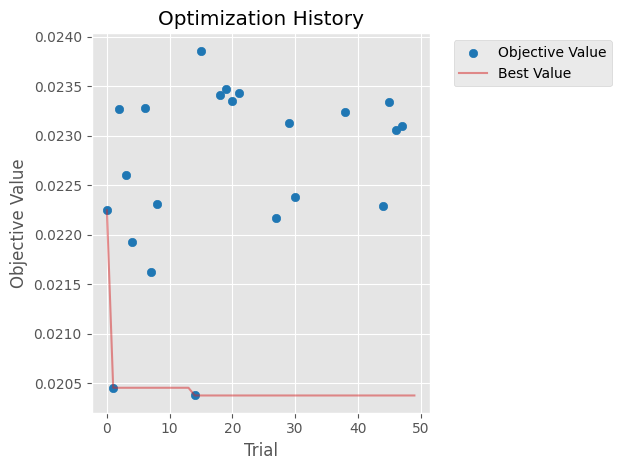

/tmp/ipykernel_13167/641041599.py:16: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


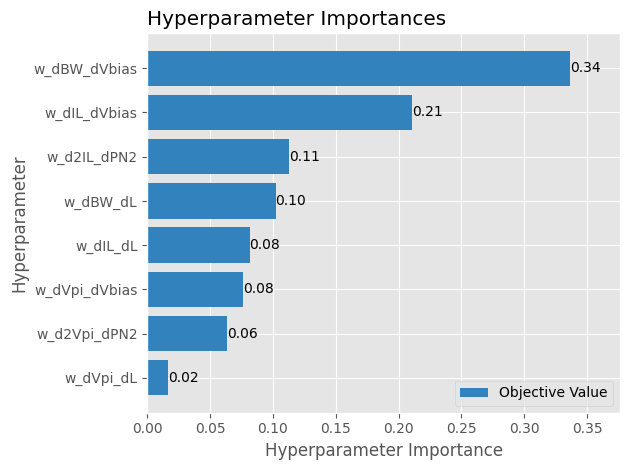

/tmp/ipykernel_13167/641041599.py:20: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  plot_parallel_coordinate(study)


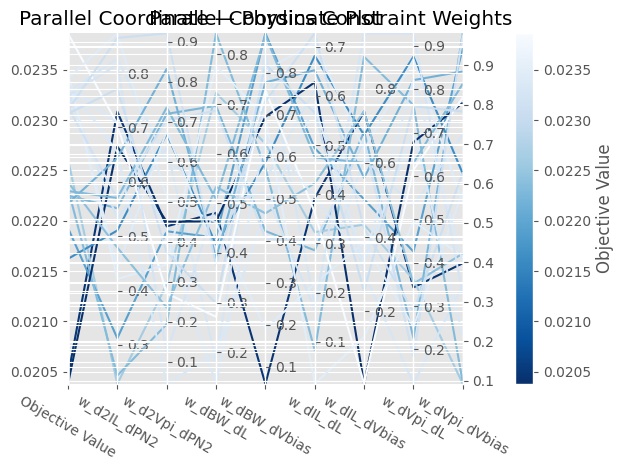

/tmp/ipykernel_13167/641041599.py:25: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  plot_slice(study)
/tmp/ipykernel_13167/641041599.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


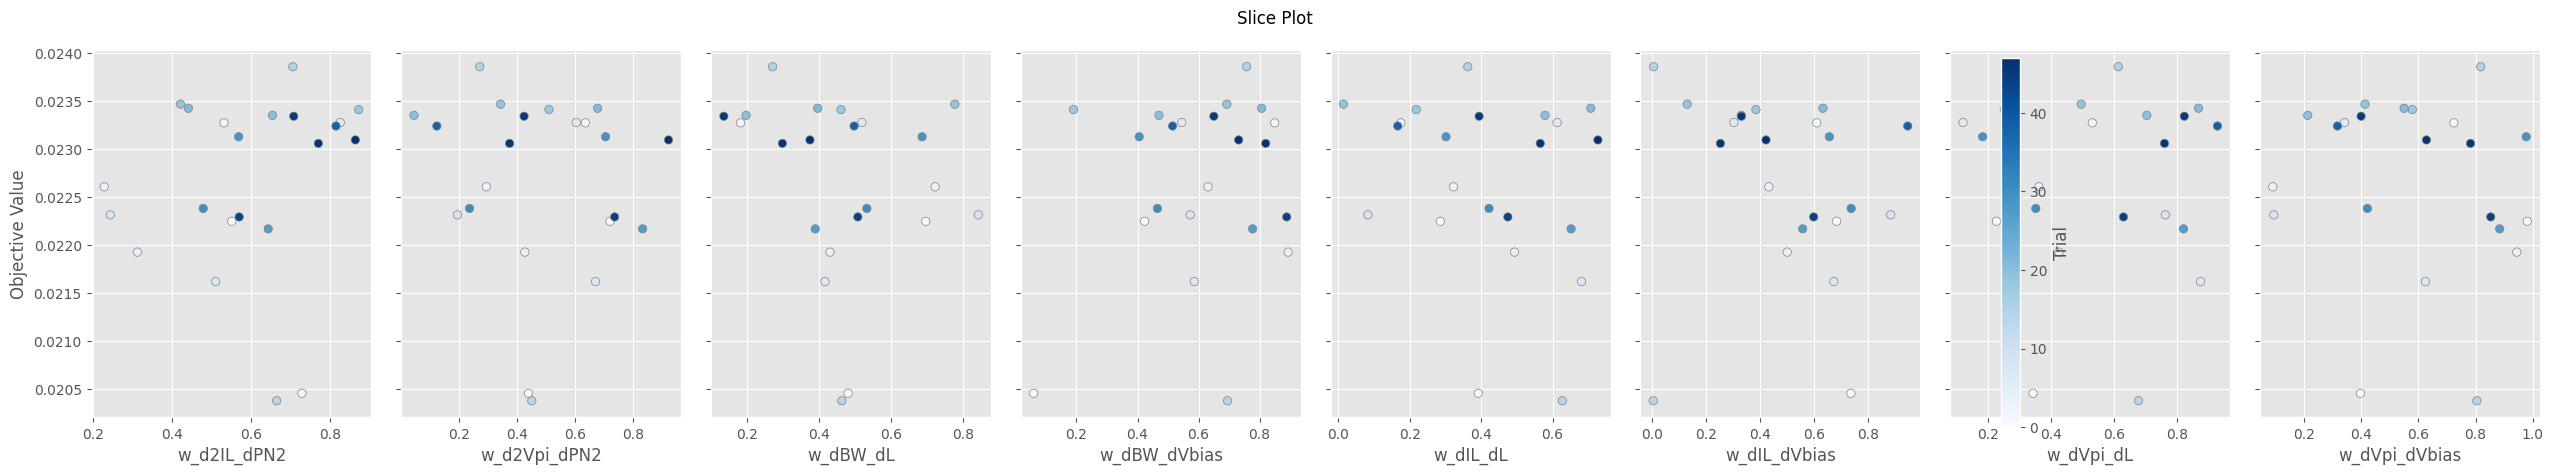

In [ ]:
# ==============================
# Optuna Visualizations
# ==============================
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_slice,
)

plot_optimization_history(study)
plt.title("Optimization History")
plt.tight_layout()
plt.show()

plot_param_importances(study)
plt.tight_layout()
plt.show()

plot_parallel_coordinate(study)
plt.title("Parallel Coordinate — Physics Constraint Weights")
plt.tight_layout()
plt.show()

plot_slice(study)
plt.tight_layout()
plt.show()


## Retrain Best Model (Full Epochs)

In [ ]:
# ==============================
# Collect best physics weights & retrain at full budget
# ==============================
bp = study.best_trial.params
best_config = {
    "hidden_dims": HIDDEN_DIMS,
    "dropout": DROPOUT,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "physics_weights": {key: bp[f"w_{key}"] for key in PHYSICS_WEIGHTS},
}

print(f"Retraining best config for {FINAL_EPOCHS} epochs ...\n")

final_result = train_model(
    model_ctor=lambda rngs: PINN(input_dim=8, output_dim=3, dropout=best_config["dropout"],
                                  hidden_dims=best_config["hidden_dims"], rngs=rngs),
    batch_size=best_config["batch_size"],
    learning_rate=best_config["learning_rate"],
    weight_decay=best_config["weight_decay"],
    physics_weights=best_config["physics_weights"],
    n_epoch=FINAL_EPOCHS,
    early_stopping_patience=FINAL_PATIENCE,
    verbose=True,
)

print(f"\nFinal Train Loss: {final_result['train_loss']:.6f}")
print(f"Final Test  Loss: {final_result['test_loss']:.6f}")
print(f"Model parameters: {final_result['n_params']}")


Retraining best config for 200 epochs ...



Training:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping at epoch 76 (best epoch: 46, best test: 0.020378)

Final Train Loss: 0.028703
Final Test  Loss: 0.020378
Model parameters: 336253


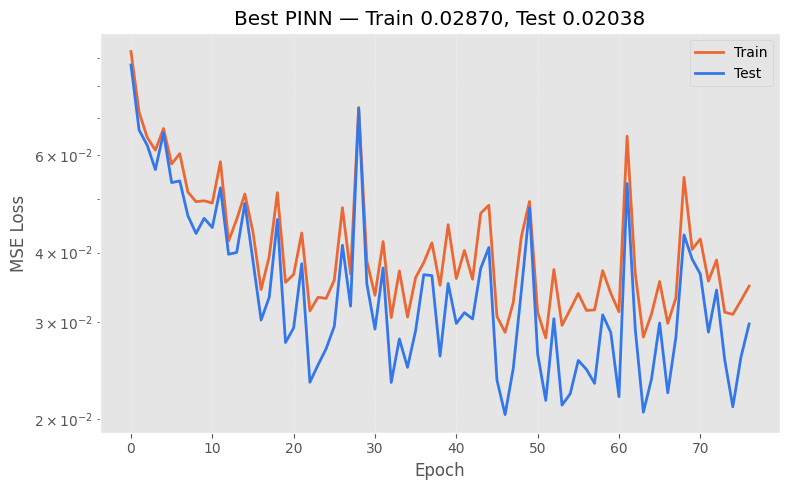

In [ ]:
# ==============================
# Training Curves for Best Model
# ==============================
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(final_result["train_history"], color="#eb6834", lw=2, label="Train")
ax.plot(final_result["test_history"], color="#3477eb", lw=2, label="Test")
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title(
    f"Best PINN — Train {final_result['train_loss']:.5f}, "
    f"Test {final_result['test_loss']:.5f}"
)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


## Per-Output Error Analysis

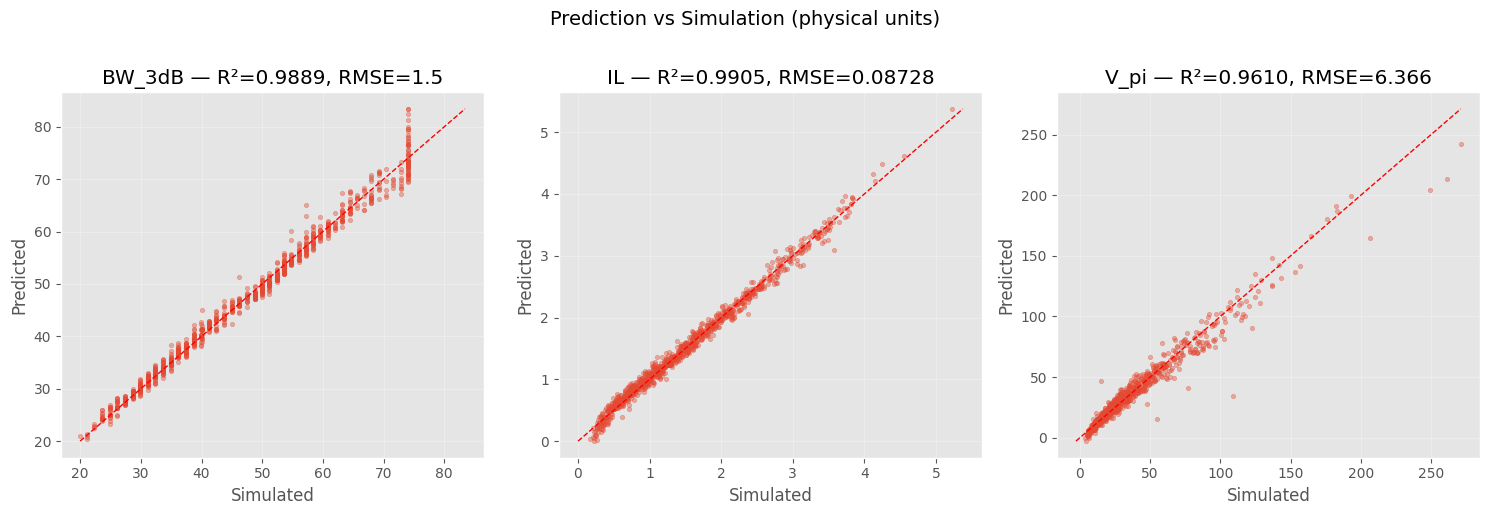

In [ ]:
# ==============================
# Per-output error analysis (physical units)
# ==============================
graphdef, params, batch_stats = final_result["model_state"]
best_model = nnx.merge(graphdef, params, batch_stats)

pred_test_scaled = np.array(best_model(x_test_t, train=False)[0])
y_test_scaled_np = np.array(y_test_t)

target_names = ["BW_3dB", "IL", "V_pi"]
scalers = [scaler_y1, scaler_y2, scaler_y3]

pred_test = np.hstack([s.inverse_transform(pred_test_scaled[:, i:i + 1]) for i, s in enumerate(scalers)])
y_test_phys = np.hstack([s.inverse_transform(y_test_scaled_np[:, i:i + 1]) for i, s in enumerate(scalers)])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (name, ax) in enumerate(zip(target_names, axes)):
    ax.scatter(y_test_phys[:, i], pred_test[:, i], alpha=0.4, s=10)
    lims = [
        min(y_test_phys[:, i].min(), pred_test[:, i].min()),
        max(y_test_phys[:, i].max(), pred_test[:, i].max()),
    ]
    ax.plot(lims, lims, "r--", lw=1)

    ss_res = np.sum((y_test_phys[:, i] - pred_test[:, i]) ** 2)
    ss_tot = np.sum((y_test_phys[:, i] - y_test_phys[:, i].mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    rmse = np.sqrt(np.mean((y_test_phys[:, i] - pred_test[:, i]) ** 2))

    ax.set_title(f"{name} — R²={r2:.4f}, RMSE={rmse:.4g}")
    ax.set_xlabel("Simulated")
    ax.set_ylabel("Predicted")
    ax.grid(True, alpha=0.3)

plt.suptitle("Prediction vs Simulation (physical units)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Save Best Configuration

In [ ]:
# ==============================
# Save best configuration & weights
# ==============================
save_dict = {
    "best_config": {**best_config, "hidden_dims": list(best_config["hidden_dims"])},
    "final_train_loss": float(final_result["train_loss"]),
    "final_test_loss": float(final_result["test_loss"]),
    "n_params": final_result["n_params"],
}

with open("best_hyperparams.json", "w") as f:
    json.dump(save_dict, f, indent=2)
print("Saved to best_hyperparams.json")

# Weights only (framework-agnostic numpy arrays) — to reload: rebuild
# `PINN(dropout=best_config["dropout"], hidden_dims=best_config["hidden_dims"], rngs=...)`,
# `nnx.split` it for a fresh graphdef/params/batch_stats, then
# `nnx.replace_by_pure_dict` each with the corresponding dict below (re-wrapped
# as jnp arrays) and `nnx.merge(graphdef, params, batch_stats)` to restore.
graphdef, params, batch_stats = final_result["model_state"]
model_weights = {
    "params": jax.tree_util.tree_map(np.array, nnx.to_pure_dict(params)),
    "batch_stats": jax.tree_util.tree_map(np.array, nnx.to_pure_dict(batch_stats)),
}
with open("best_model.pkl", "wb") as f:
    pickle.dump(model_weights, f)
print("Saved model weights to best_model.pkl")

print("\nBest configuration summary:")
print(json.dumps(save_dict, indent=2))


Saved to best_hyperparams.json
Saved model weights to best_model.pkl

Best configuration summary:
{
  "best_config": {
    "hidden_dims": [
      200,
      300,
      350,
      300,
      200
    ],
    "dropout": 0.2,
    "batch_size": 16,
    "learning_rate": 0.001,
    "weight_decay": 0.05,
    "physics_weights": {
      "dBW_dL": 0.46368457667812574,
      "dIL_dL": 0.6275831161541958,
      "dVpi_dL": 0.6782328144436551,
      "d2IL_dPN2": 0.6650518869891311,
      "d2Vpi_dPN2": 0.4501381158930827,
      "dBW_dVbias": 0.69491025412831,
      "dVpi_dVbias": 0.8047193258410612,
      "dIL_dVbias": 0.004941480271880017
    }
  },
  "final_train_loss": 0.02870270237326622,
  "final_test_loss": 0.020378172397613525,
  "n_params": 336253
}
